Progetto Pratica: "Model Swapping" (Sostituzione dell'Architettura)

In [1]:
import tensorflow as tf
import numpy as np
import requests

from PIL import Image
from io import BytesIO

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions

print("Librerie importate. Pronto per VGG16.")

Librerie importate. Pronto per VGG16.


In [2]:
IMMAGINE_URL = "https://images.pexels.com/photos/337909/pexels-photo-337909.jpeg"

print(f"URL impostato: {IMMAGINE_URL}")

URL impostato: https://images.pexels.com/photos/337909/pexels-photo-337909.jpeg


In [3]:
def carica_modello_vgg():
    print("Caricamneto del modello VGG16...")

    model = VGG16( weights="imagenet", include_top=True)

    return model

model = carica_modello_vgg()

print("Modello VGG16 caricato correttamente.")

Caricamneto del modello VGG16...
Modello VGG16 caricato correttamente.


In [4]:
def ottieni_e_processa_immagine(url):
    print("Download e preprocessing dell'immagine...")

    response = requests.get(url)
    response.raise_for_status()

    img = Image.open(BytesIO(response.content)).convert("RGB")
    img = img.resize((224, 224))

    x = np.array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    return x, img
processed_image, img = ottieni_e_processa_immagine(IMMAGINE_URL)

print("Immagine pronta per VGG16.")
print("Forma:", processed_image.shape)

Download e preprocessing dell'immagine...
Immagine pronta per VGG16.
Forma: (1, 224, 224, 3)


In [13]:
def classifica_immagine(model, processed_image):
    print("Classificazione in corso...")

    predictions = model.predict(processed_image)

    results = decode_predictions(predictions, top=5) [0]

    return results

results = classifica_immagine(model, processed_image)

print("Classificazione completata.")

Classificazione in corso...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Classificazione completata.


In [6]:
print("Top 5 previsioni VGG16:\n")

for i, (_, label, probability) in enumerate(results, start=1):
    print(f"{i}. {label}:{probability * 100:.2f}%")

Top 5 previsioni VGG16:

1. sports_car:80.89%
2. convertible:5.78%
3. grille:3.91%
4. cab:2.92%
5. racer:2.09%


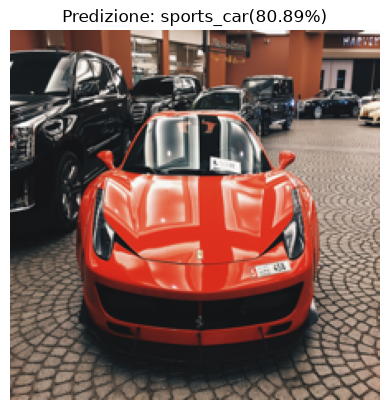

In [14]:
import matplotlib.pyplot as plt

top_label = results[0][1]
top_probability = results[0][2] * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Predizione: {top_label}({top_probability:.2f}%)")
plt.show()